# Aprendizagem Automática - Diagnóstico de Tumores Cerebrais

- Docente: 
  - Teresa Gonçalves

- Alunos:
  - Miguel Pombeiro (57829)
  - Miguel Rocha (58501)
  - Rodrigo Santos (46320)


## Introdução

Este relatório documenta o desenvolvimento de modelos de aprendizagem automática para o diagnóstico de tumores cerebrais, no âmbito da unidade curricular de Aprendizagem Automática. 
O objetivo principal é a previsão do diagnóstico baseada numa combinação de características demográficas do paciente e da textura extraídas de imagens ADC (*Apparent Diffusion Coefficient*) de ressonância magnética (RM).

Para além do objetivo principal de desenvolver modelos robustos, procuramos:
- Avaliar diferentes técnicas de pré‑processamento e normalização;
- Comparar metodologias de agregação de informação por paciente;
- Testar múltiplos algoritmos de aprendizagem supervisionada;
- Procurar os melhores hiperparâmetros para os modelos;
- Avaliar estratégias de agregação que maximizam o *Score* F1;

A complexidade do problema está relacionada com a estrutura do *dataset*, que contém múltiplas *slices* por paciente num conjunto de treino, com tamanho relativamente reduzido, exigindo um tratamento de dados cuidadoso.

O projeto foi desenvolvido em Python, recorrendo às bibliotecas `scikit‑learn`, `pandas`, `numpy`, `seaborn` e `matplotlib`.

No total, foram realizadas 14 submissões na plataforma, abrangendo modelos de diferentes naturezas — desde classificadores lineares a métodos baseados em vizinhança, árvores de decisão e técnicas de comités. O relatório apresenta uma descrição detalhada de todo o processo, desde a análise inicial do dados até à caracterização dos três modelos escolhidos.


## Conjunto de dados

Os dados fornecidos estão separados em dois subconjuntos, o conjunto de treino (treino.csv) e o conjunto de teste (teste.csv). 

O conjunto de treino, é o conjunto que será usado para treinar os nossos modelos, contendo portanto, já diagnósticos reais de cada uma das imagens. 

O conjunto de teste, é o conjunto ao qual pretendemos aplicar o nosso modelo, de modo a conseguir classificar os tumores dos pacientes, de uma maneira confiável. É a partir deste que será realizada a submissão dos diagnósticos para a competição na plataforma kaggle, avaliada em duas partes, parte pública e parte privada.

### Caracterização dos dados

A partir dos ficheiros `teste.csv` e `treino.csv`, é possível identificar 18 atributos descritivos, aos quais cada paciente terá informações sobre:
- **atributo categórico:** `sexo`
- **atributo numéricos:** `id`, `idade`, `id_fatia`, `med_ADC`, `assimetria`, `curtose`,   `med1_GLCM`, `med2_GLCM`, `var1_GLCM`, `var2_GLCM`, `energia_GLCM`, `entropia_GLCM`,  `contraste_GLCM`, `homogeneidade_GLCM`, `correlação_GLCM`, `proiminência_GLCM`, `sombra_GLCM`
- **atributo alvo:** `diagnostico`



É ainda possível contar o número de instâncias das classes do diagnóstico bem como a sua porcentagem, o que nos permite ter uma melhor compreensão dos dados disponíveis. É de notar que estes dados foram retirados antes de quaisquer agregação dos dados, ou seja, não tem em conta as *slices* de cada paciente.

Instâncias por classe (maligno(1) ou benigno(0)):
diagnostico
1    758
0    635
Name: count, dtype: int64

Total de instâncias: 1393

Instâncias por classe (%):
diagnostico
1    54.41
0    45.59
Name: proportion, dtype: float64


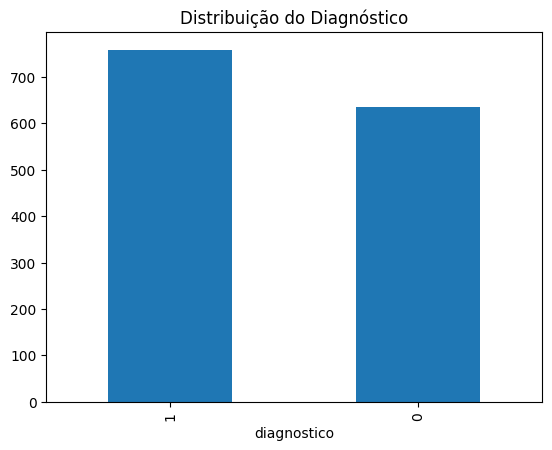

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv("../data/treino.csv")

#Contagem de instâncias por classe
print("Instâncias por classe (maligno(1) ou benigno(0)):")
print(data['diagnostico'].value_counts(dropna=False))
print("\nTotal de instâncias:", data['diagnostico'].value_counts().sum())

#Percentagem de instâncias por classe
print("\nInstâncias por classe (%):")
print(data['diagnostico'].value_counts(normalize=True).mul(100).round(2))

data['diagnostico'].value_counts().plot(kind='bar')
plt.title('Distribuição do Diagnóstico')
plt.show()

Antes de fazer qualquer agregação ou processamento aos dados, verificamos que os dados se apresentam bastante balanceados.

Após estas informações, foi realizada uma breve descrição dos nossos dados de treino, para identificar se existiam valores em falta, bem como verificar os outliers, entre outras informações importantes que serão analisadas posteriormente. 

É também necessário fazer o mapeamento do atributo categórico existente (sexo) para valores numéricos, de modo a que estes sejam considerados pelos algoritmos. Sendo assim o sexo masculino (m) foi mapeado para 0 e o sexo feminino para 1.

O seguinte código irá criar essa tabela, com a descrição dos dados, bem como o mapeamento referido.

In [2]:
ATTRIBUTES_TO_IGNORE = ['id', 'diagnostico', 'id_fatia']
data_to_describe = data.copy()
data_to_describe.drop(ATTRIBUTES_TO_IGNORE, axis=1, inplace=True)
data_to_describe["sexo"] = data_to_describe["sexo"].map({"m": 0, "f": 1})
data["sexo"] = data["sexo"].map({"m": 0, "f": 1})
data_to_describe.describe()

,idade,sexo,med_ADC,assimetria,curtose,med1_GLCM,med2_GLCM,var1_GLCM,var2_GLCM,energia_GLCM,entropia_GLCM,contraste_GLCM,homogeneidade_GLCM,correlação_GLCM,proiminência_GLCM,sombra_GLCM
count,1393.000000,1393.000000,1393.000000,1393.000000,1393.000000,1393.000000,1393.000000,1393.000000,1393.000000,1393.000000,1393.000000,1393.000000,1393.000000,1393.000000,1393.000000,1393.000000
mean,46.450826,0.549174,1108.658307,5.134572,0.726991,8.969625,9.183479,4.376971,6.594537,0.081952,3.205197,5.169363,0.546917,0.504739,0.887137,1.252377
std,18.770829,0.497755,412.748470,4.135578,1.052737,3.519968,3.397307,5.281116,7.473869,0.072727,0.770853,5.725974,0.128801,0.175807,0.968834,1.366289
min,1.000000,0.000000,282.689000,1.550000,-4.750000,2.087000,2.483000,0.134000,0.150000,0.008000,0.942000,0.240000,0.185000,-0.083000,-2.650000,-3.297000
25%,36.000000,0.000000,860.840000,2.960000,0.100000,6.852000,7.031000,1.160000,2.012000,0.034000,2.672000,1.750000,0.458000,0.400000,0.703000,1.328000
50%,50.000000,1.000000,1051.316000,3.792000,0.634000,8.473000,8.709000,2.700000,4.119000,0.056000,3.294000,3.273000,0.546000,0.529000,1.088000,1.549000
75%,60.000000,1.000000,1265.033000,5.777000,1.348000,10.300000,10.625000,5.354000,8.219000,0.104000,3.766000,6.398000,0.638000,0.633000,1.424000,1.901000
max,91.000000,1.000000,2993.487000,72.763000,7.469000,25.077000,24.621000,44.724000,62.452000,0.543000,5.141000,55.116000,0.883000,0.914000,4.584000,6.016000


<a id="tab1"></a>
**Tabela 1 — Descrição dos dados de treino**

### Análise e exploração do conjunto de dados

A partir das informações obtidas na tabela anterior [Tabela 1](#tab1), é possível verificar:
- Não existem valores em falta, já que, o *count* para todos os atributos é o mesmo. 
- Existem outliers, mas esses irão ser analisados mais adiante, com base nas caixas de bigodes (boxplot). 
- Existe uma diferença de escala muito grande entre atributos, que poderá afetar alguns algoritmos, necesitando de os normalizar. 
- Existem também atributos com valores negativos/assimetria à esquerda, como por exemplo curtose, proiminência_GLCM e sombra_GLCM.

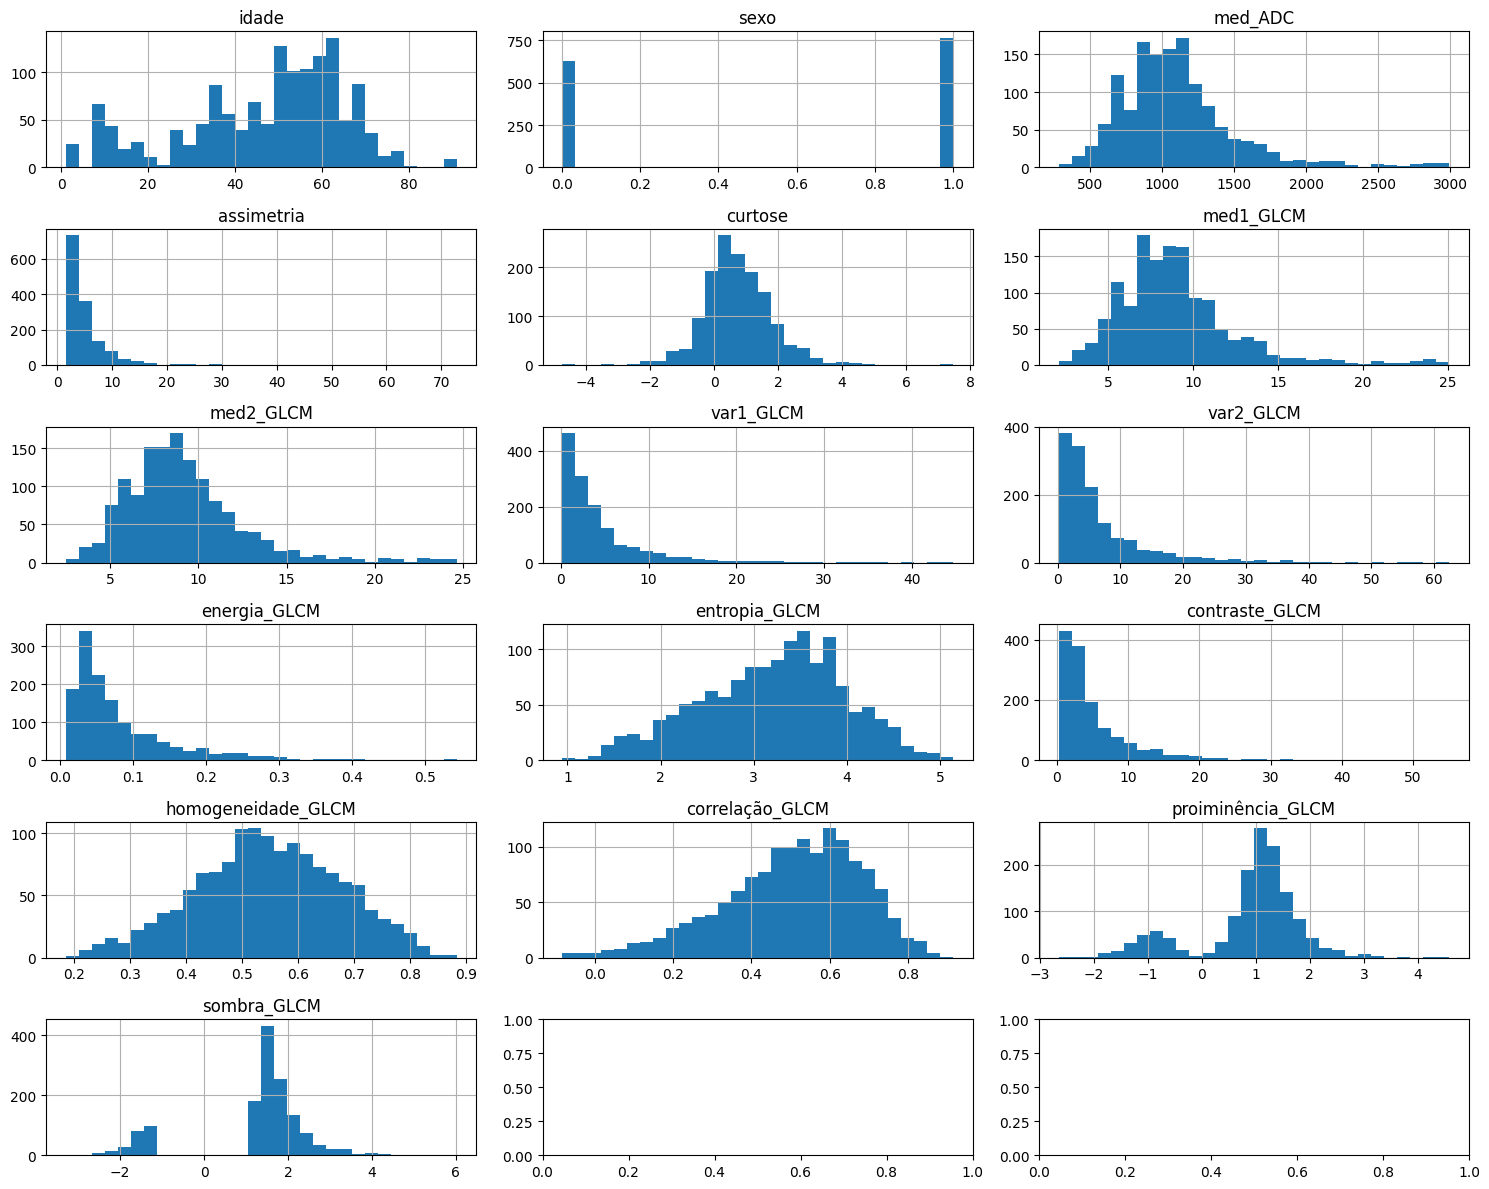

In [3]:
fig, axes = plt.subplots(6, 3, figsize=(15,12))
axes = axes.flatten()
cols = data_to_describe.columns[:16]

for i, col in enumerate(cols):
    data_to_describe[col].hist(ax=axes[i], bins=30)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


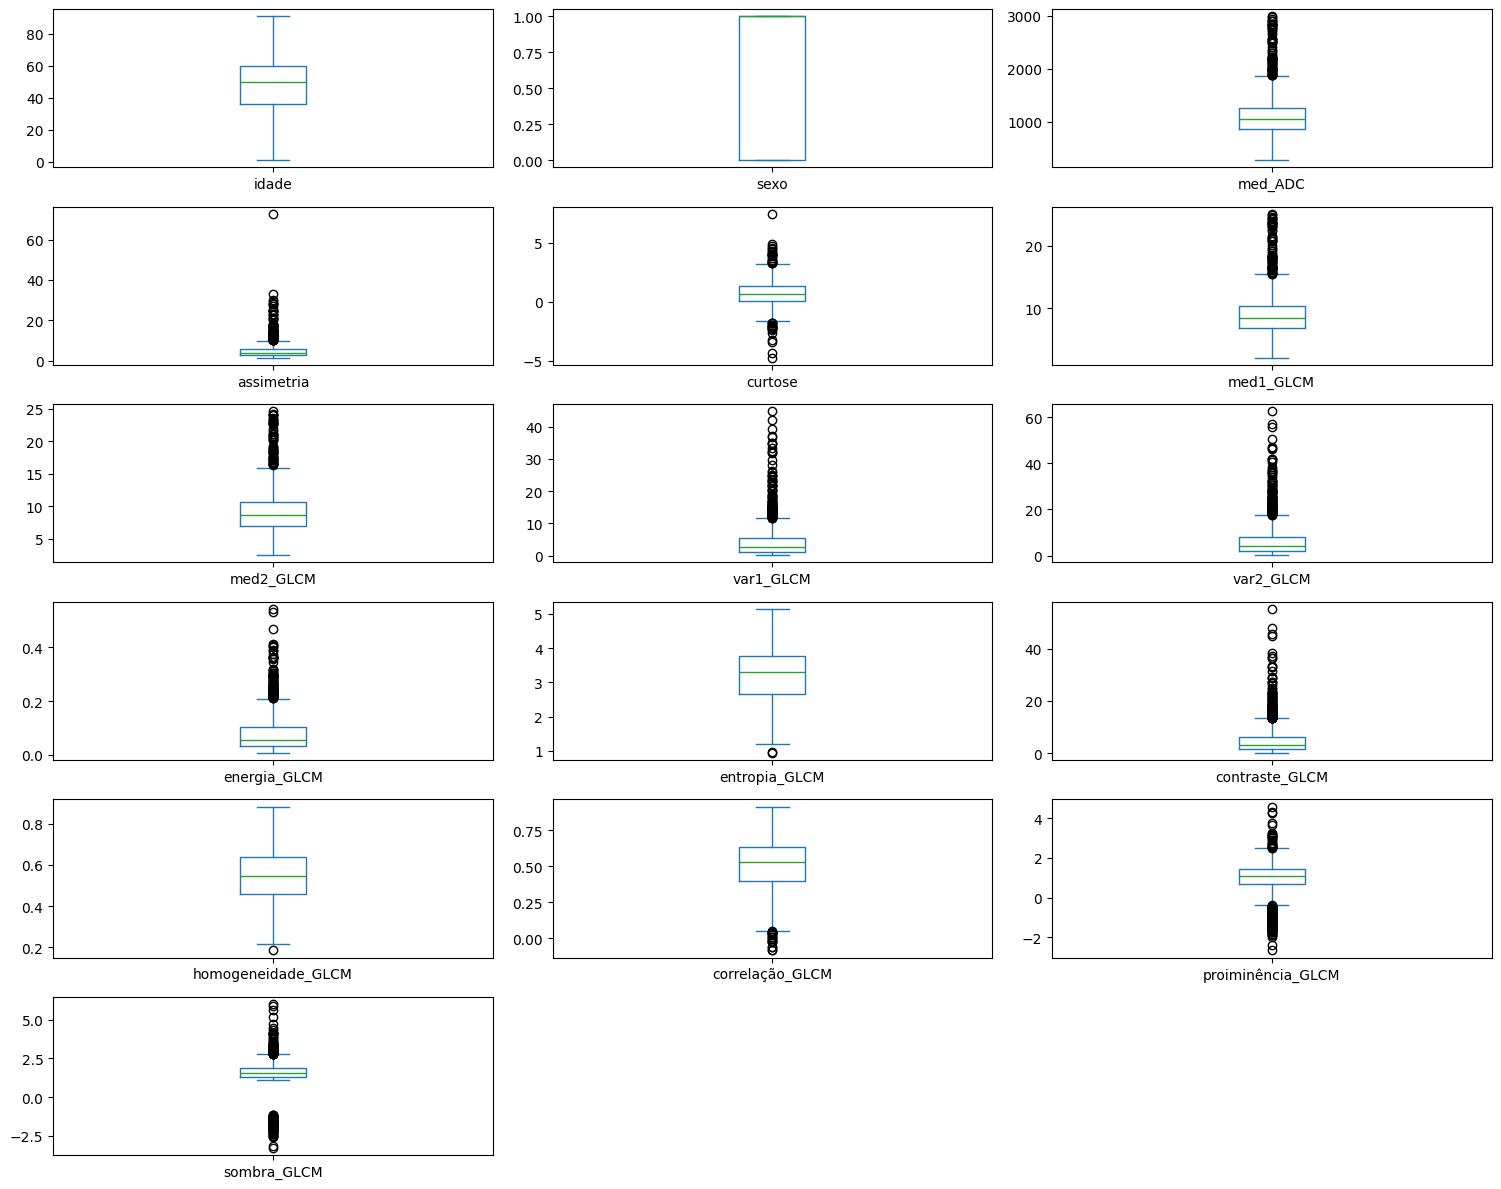

In [4]:
import matplotlib.pyplot as plt
data_to_describe.plot(kind='box', subplots=True, layout=(6,3), figsize=(15,12))
plt.tight_layout()
plt.show()

A partir das caixas de bigodes (boxplot) de cada um dos atributos, é possível verificar que existem muitos *outliers*, especialmente para os atributos 'med_ADC', 'assimetria', 'med1_GLCM', 'med2_GLCM', 'var1_GLCM', 'var2_GLCM', 'energia_GLCM', 'contraste_GLCM', 'correlação_GLCM', 'proiminência_GLCM'' e 'sombra_GLCM'. 
Para estes atributos é necessário corrigi-los, e portanto, necessitamos de aplicar transformações. Para tal, aplicaremos as transformações por fórmulas matemáticas, como por exemplo o logaritmo. 

É necessário também ter atenção que a função do logaritmo só poderá ser aplicada nos atributos com valores positivos, sendo portanto necessário usar outra função para os atributos com valores negativos, como por exemplo yeo-johnson. Este é apenas um exemplo de uma transformação aos dados, que poderá ou não ser usado mais tarde.

In [5]:
import numpy as np
from sklearn.preprocessing import PowerTransformer

ATTRIBUTES_TO_TRANSFORM_WITH_POSITIVE_VALUES = ['med_ADC', 'assimetria', 'med1_GLCM', 'med2_GLCM', 'var1_GLCM', 'var2_GLCM', 'energia_GLCM', 'contraste_GLCM']
ATTRIBUTES_TO_TRANSFORM_WITH_NEGATIVE_VALUES = ['correlação_GLCM', 'proiminência_GLCM', 'sombra_GLCM']
transformed_data = data_to_describe.copy()
for attr in ATTRIBUTES_TO_TRANSFORM_WITH_POSITIVE_VALUES:
    transformed_data[attr] = np.log1p(transformed_data[attr])


pt = PowerTransformer(method='yeo-johnson')
for attr in ATTRIBUTES_TO_TRANSFORM_WITH_NEGATIVE_VALUES:
    transformed_data[attr] = pt.fit_transform(transformed_data[[attr]])


Assim, após realizar estas alterações, os seguintes dados já não apresentam caudas tão grandes na direita, e apresentam menos simetria.

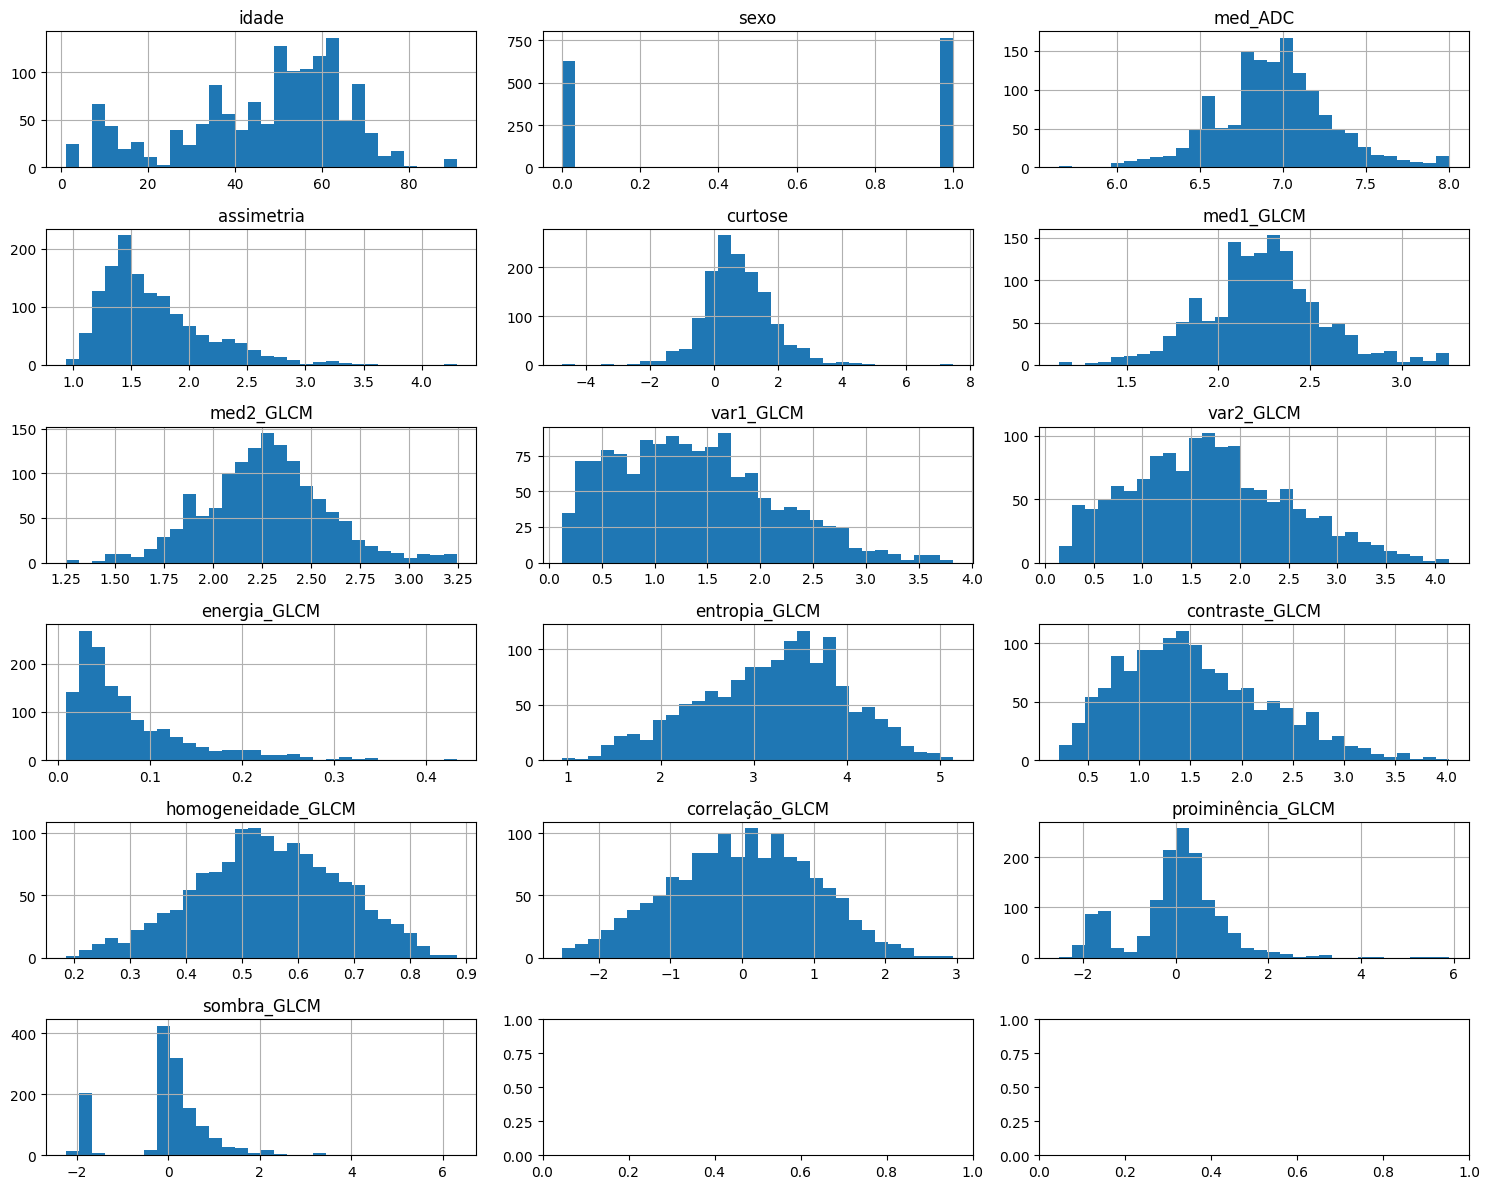

In [6]:
fig, axes = plt.subplots(6, 3, figsize=(15,12))
axes = axes.flatten()
cols = transformed_data.columns[:16]

for i, col in enumerate(cols):
    transformed_data[col].hist(ax=axes[i], bins=30)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

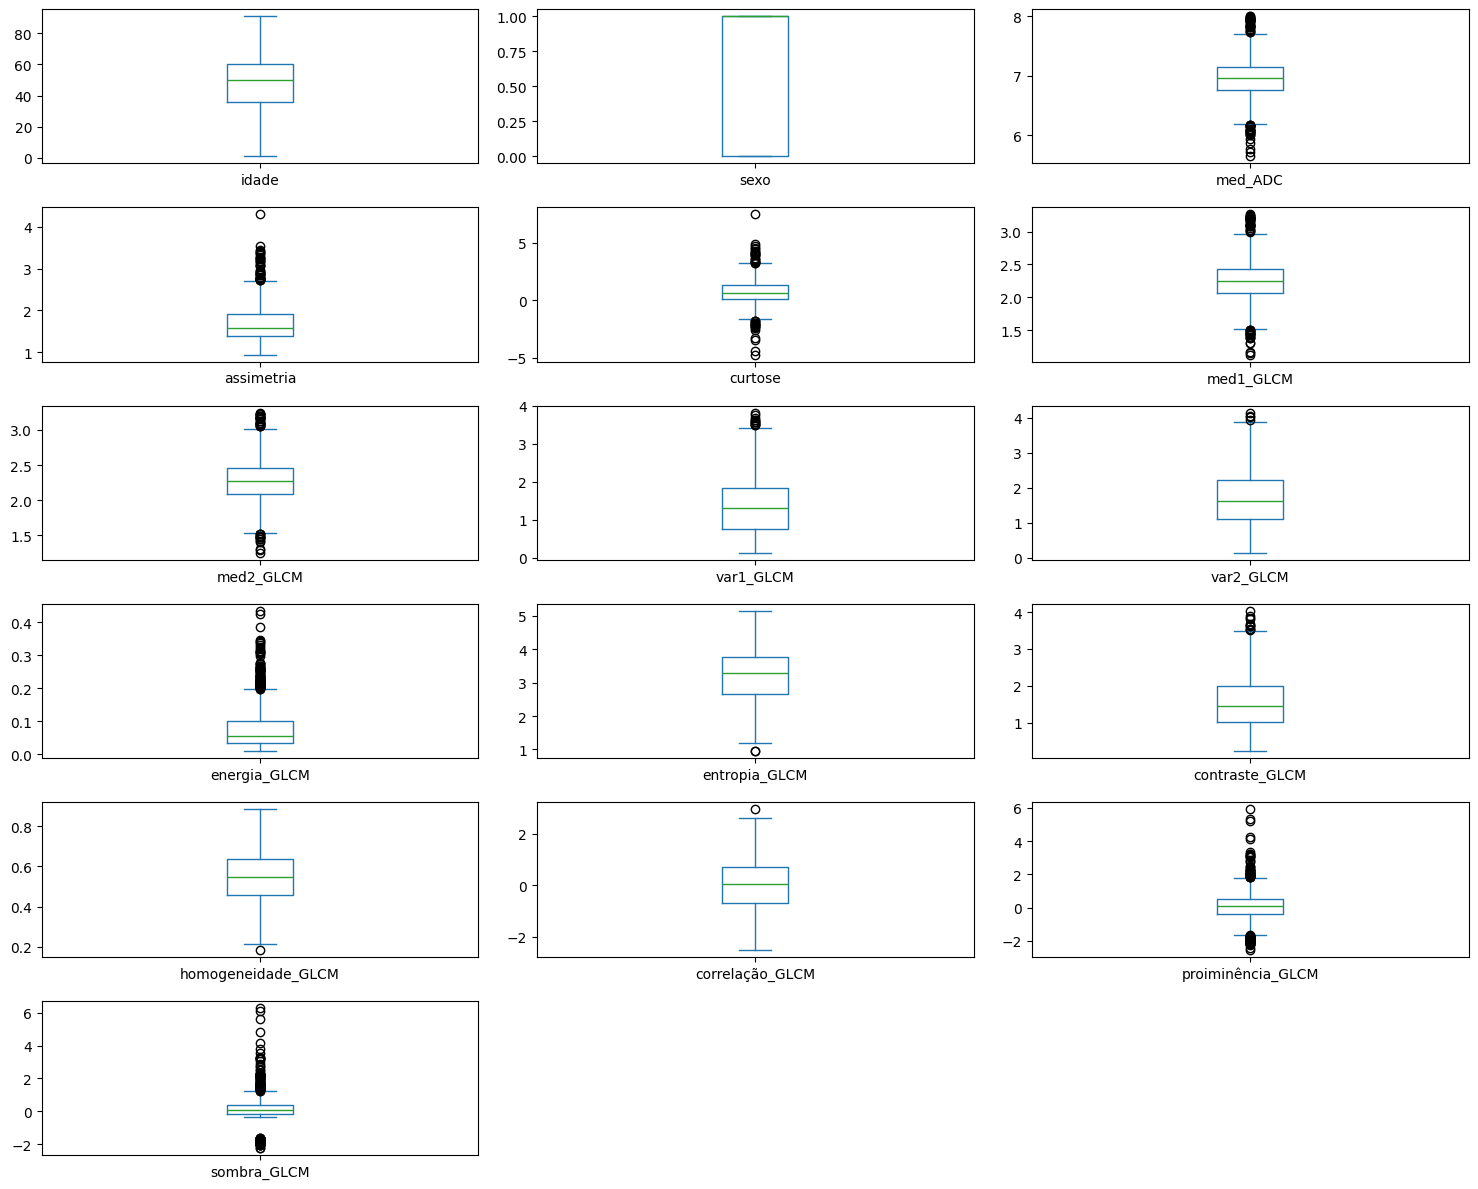

In [7]:
transformed_data.plot(kind='box', subplots=True, layout=(6,3), figsize=(15,12))
plt.tight_layout()
plt.show()

Como é possível analisar, o número de outliers reduziu drasticamente, sendo útil para modelos lineares.

Agora também é possível analisar a correlação entre os atributos do nosso conjunto de dados, estando a informação presente nos próximos gráficos, (pairplot e heatmap).

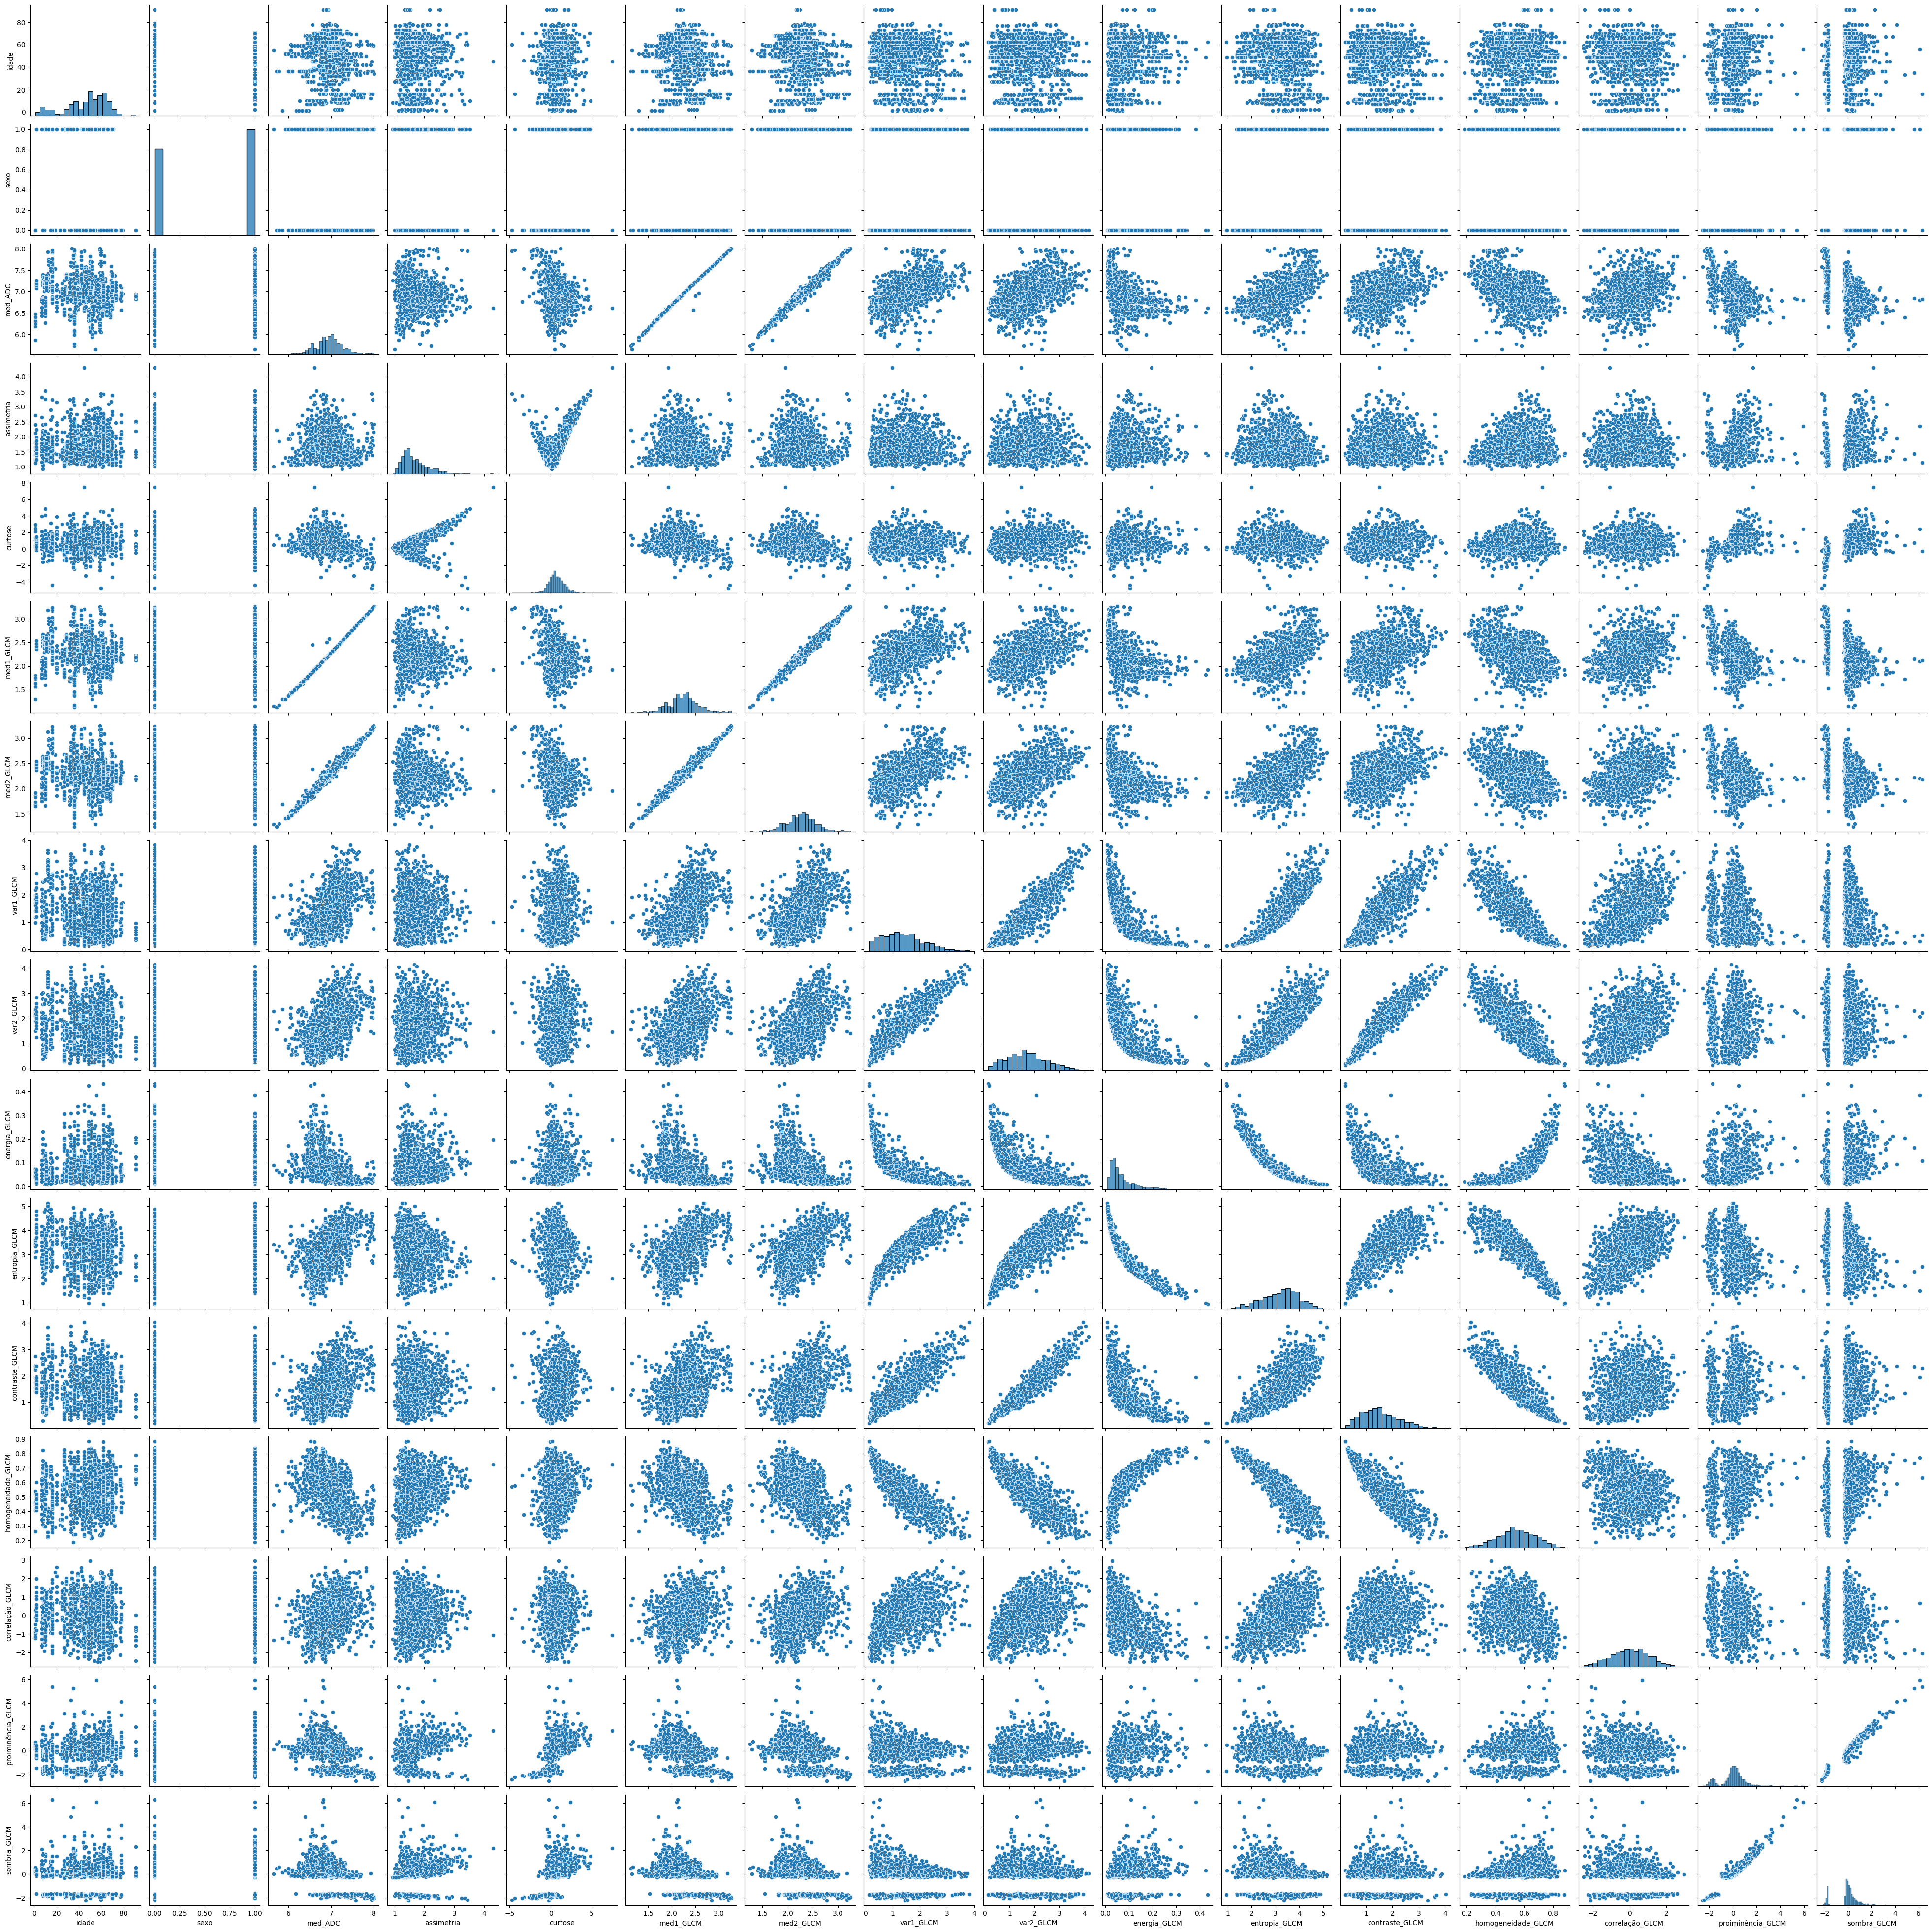

In [8]:
import seaborn as sns

sns.pairplot(transformed_data)

Se existir correlação linear entre dois atributos, o gráfico apresentará uma forma parecida a uma reta (terá um declive positivo se a correlação for positiva, e terá um declive negativo se a correlação for negativa).

<Figure size 1200x1000 with 0 Axes>

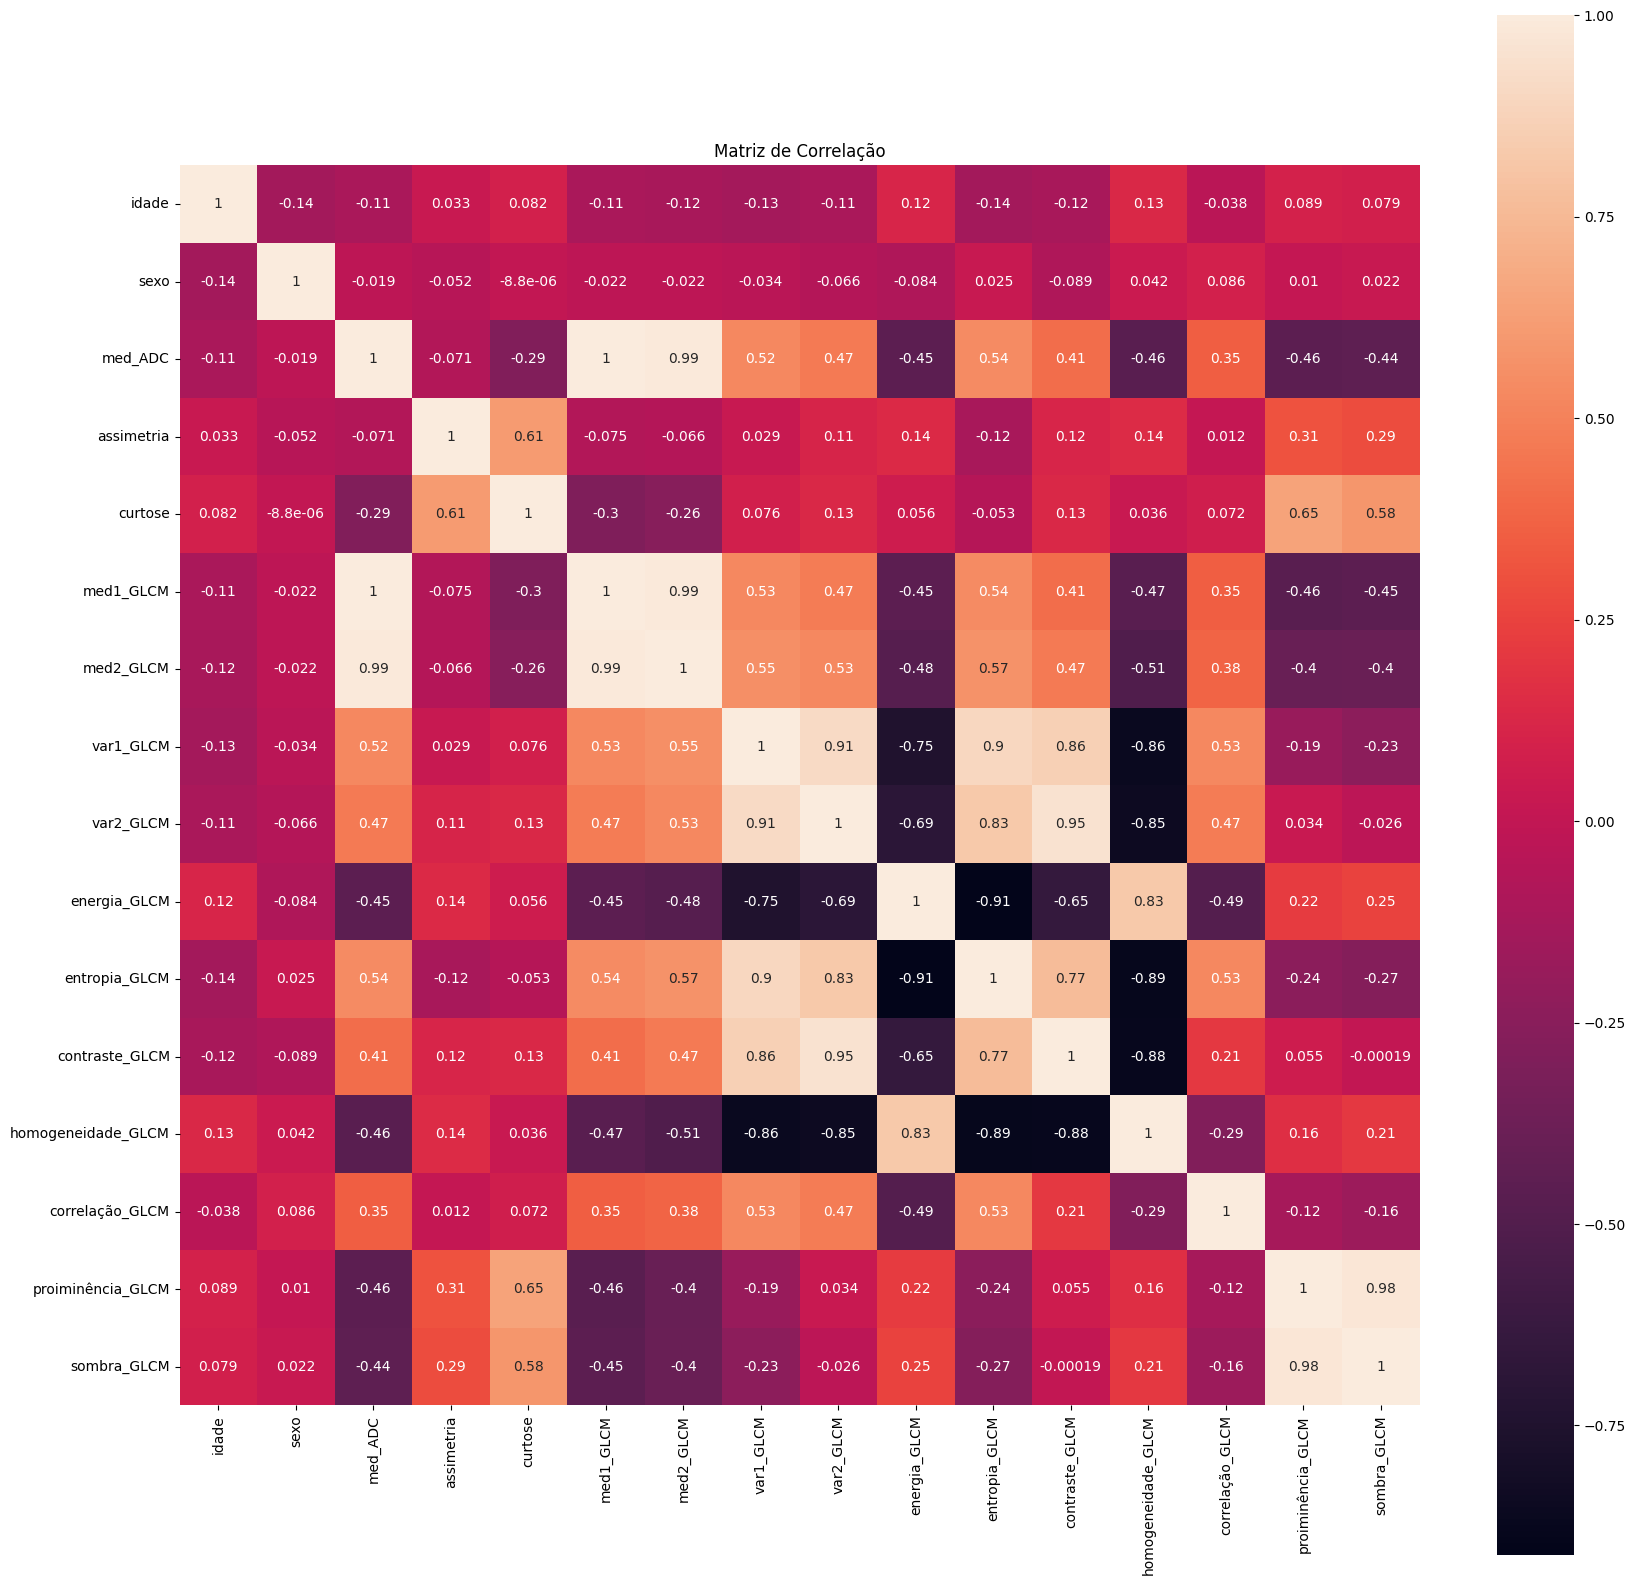

In [9]:
corr = transformed_data.corr()
plt.figure(figsize=(12, 10))

plt.figure(figsize=(20, 20))

sns.heatmap(corr, annot=corr, square=True)
plt.title("Matriz de Correlação")
plt.show()


Assim, é possível verificar a existência de correlações lineares altas, especialmente para os seguintes pares de atributos:

- (proiminência_GLCM, sombra_GLCM), com correlação 0.98
- (med1_GLCM, med2_GLCM), com correlação 0.99
- (var1_GLCM, var2_GLCM), com correlação 0.91
- (energia_GLCM, entropia_GLCM), com correlação -0.91
- (contraste_GLCM, homogeneidade_GLCM) com correlação -0.88
- (med2_GLCM, med_ADC), com correlação 0.99
- (med1_GLCM, med_ADC), com correlação 1.0

Como os valores de correlação são elevados (|correlação| > 0.87), é possível removê-los ou agregá-los de modo a existir menos influência nos valores dos modelos lineares. Apesar destes atributos apresentarem valores altos, como apresentam algum significado por trás no domínio médico, decidimos não fazer alguma alteração. Assim para o algoritmo de regressão linear será usada o Regularização L2, já que esta penaliza os grandes coeficientes, tornando-os menos sensíveis à multicolinearidade.

**Nota: O valor 0.87 é um valor arbitrário e seria necessário testar e pesquisar melhor sobre o melhor valor a utilizar**.

## Experiências realizadas para a pesquisa dos melhores modelos

De forma a encontrar os melhores modelos para fazer a classificação dos pacientes, foram testados diferentes algoritmos de aprendizagem supervisionada, diferentes formas de pré-processamento dos dados, e diferentes formas de fazer uma agregação por paciente.
A agregação de dados para previsão foi o ponto principal que vamos utilizar para dividir as nossas experiências, uma vez que foram necessárias diferentes metodologias para testar cada uma das abordagens. Assim, nesta secção, vamos descrever as várias metodologias utilizadas, divididas pelas duas abordagens de agregação testadas: **agregação antes** (previsão por paciente) e **agregação depois** (previsão por *slice*).

### Transformações dos dados

#### Remoção de colunas que não são atributos

Antes de qualquer transformação ou treino dos modelos, foi necessário remover do conjunto de dados as colunas que não são atributos, nomeadamente as colunas "id" (identificador do paciente e de *slice*) e "diagnostico" (*label*/etiqueta). Isso foi feito de forma a evitar que estas colunas influenciassem o treino dos modelos, uma vez que não são atributos relevantes para a classificação dos pacientes.

A título de exemplo, o código utilizado para fazer esta separação no fluxo de **agregação depois** é o seguinte:

In [6]:
def remove_non_feature_columns(
        df, 
        id_col="id", 
        target_col="diagnostico"):
    """
    Remove non-feature columns (ID, target) from the DataFrame.
    The function will remove columns: id_col, target_col, and "id_fatia" if they exist.
    It will also return the target variable and patient groups for later use.

    :param df: DataFrame with slice-level data.
    :param id_col: Column name for patient ID.
    :param target_col: Column name for target variable.
    :return: Features DataFrame without ID, target columns and groups
    """
    columns_to_remove = [id_col, target_col, "id_fatia"]

    # target column
    if target_col in df.columns:
        y = df[target_col].astype(int)
    else:
        y = None

    # patient IDs for grouping later
    groups = df[id_col].copy() 

    # features DataFrame without non-feature columns
    X = df.drop(columns=columns_to_remove, errors="ignore")
    X = X.select_dtypes(include=[np.number])

    return X, y, groups

#### Atributos Categóricos

Como já foi referido, uma das primeiras situações que é possível observar ao analisar o conjunto de dados é que o atributo "sexo" é um atributo categórico, que pode assumir os valores "m" (masculino) e "f" (feminino). No entanto, a maioria dos algoritmos de aprendizagem automática não conseguem lidar diretamente com atributos categóricos, sendo necessário convertê-los em atributos numéricos. 

Para tal, e uma vez que foram utilizados *dataframes* do *pandas* para armazenar os dados, foi utilizada a função `map`, que permite mapear os valores "m" e "f" para os valores numéricos 0 e 1, respetivamente.

#### Normalização dos dados

Alguns algoritmos de aprendizagem automática (e.g. SVM, KNN, Regressão Logística) são sensíveis à escala dos atributos e à existência de *outliers* nos dados. Para lidar com estes problemas, foram testadas diferentes técnicas de normalização dos dados, nomeadamente o `StandardScaler`, que normaliza os dados para terem média 0 e desvio padrão 1, e o `PowerTransformer` (Yeo-Johnson), já referido na Secção 1, que aplica uma transformação não linear aos dados para torná-los mais próximos de uma distribuição normal.

De forma a facilitar a aplicação destas transformações, foram utilizados os `ColumnTransformer` do *sklearn*, que permitem aplicar diferentes transformações a diferentes colunas dos dados.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
#Do not process binary ("sexo") columns with scalers or transformers
def get_preprocessors(X_train):
    """
    Create different preprocessors for scaling and transforming data.

    :param X_train: Training features DataFrame.
    :return: Three ColumnTransformer objects for different preprocessing strategies.
    """
    binary_cols = ["sexo"]
    cont_cols = [col for col in X_train.columns if col not in binary_cols]

    preprocessor_scaler = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), cont_cols),
            ("bin", "passthrough", binary_cols)
        ]
    )

    preprocessor_power = ColumnTransformer(
        transformers=[
            ("num", PowerTransformer(method='yeo-johnson', standardize=True), cont_cols),
            ("bin", "passthrough", binary_cols)
        ]
    )

    preprocessor_combined = ColumnTransformer(
        transformers=[
            ("num", Pipeline([ 
                ("pt", PowerTransformer(method='yeo-johnson', standardize=False)),
                ("scaler", StandardScaler()),
            ]), cont_cols),
            ("bin", "passthrough", binary_cols)
        ]
    )
    return preprocessor_scaler, preprocessor_power, preprocessor_combined


Estas transformações foram depois aplicadas utilizando o `Pipeline` do *sklearn*, que permite encadear várias transformações e um modelo de aprendizagem automática num único objeto, facilitando o processo de treino e validação dos modelos.

#### Escolha de atributos

A escolha dos atributos mais correlacionados entre o diagnóstico, fez também parte de alguns dos testes que realizamos. Apesar do nosso conjunto de dados conter 18 atributos descritivos, o que achamos ser suficiente, decidimos remover alguns dos atributos com menos correlação com o resultado final, de modo a analisar o comportamento com menos atributos e mais correlacionados com a etiqueta.

### Procura dos melhores hiperparâmetros, Validação Cruzada

Para a procura dos melhores hiperparâmetros dos diferentes modelos testados, foi utilizada a técnica de validação cruzada com 5 folds, estratificada por paciente. Esta técnica permite avaliar o desempenho do modelo de forma mais robusta, evitando o *overfitting* e garantindo que o modelo generaliza bem para novos dados.
Esta validação cruzada foi realizada utilizando o `GridSearchCV` do *sklearn*, que dados um conjunto de hiperparâmetros a testar, realiza uma procura exaustiva pelos melhores valores, utilizando a validação cruzada para avaliar o desempenho do modelo com cada combinação de hiperparâmetros. Tal como utilizado no Kaggle, a métrica de avaliação utilizada foi o **F1-score**, que combina a precisão e a cobertura, e é especialmente útil em problemas de classificação binária.

Para garantir que a validação cruzada é estratificada, quando se utiliza o método de **agregação antes**, foi utilizado o `StratifiedKFold` do *sklearn*, que permite fazer uma validação cruzada estratificada, garantindo que a proporção de classes é mantida em cada *fold*.
Já quando se utiliza o método de **agregação depois**, foi utilizado o `StratifiedGroupKFold` do *sklearn*, que permite fazer uma validação cruzada estratificada por pacientes, garantindo que as *slices* do mesmo paciente não são divididas entre o conjunto de treino e o conjunto de validação, para evitar *data leakage*.

### Agregação dos dados

Como já foi referido, o *dataset* para este trabalho é composto por várias *slices* de diferentes pacientes, sendo que o diagnóstico é feito ao nível do paciente. Contudo, este *dataset* de treino não é muito grande (contém apenas 1393 *slices* para 186 pacientes), o que dificulta a tarefa de treinar modelos de aprendizagem automática. Assim e em discussão com a professora, decidimos tentar duas abordagens diferentes para lidar com a agregação dos dados por paciente, de forma a tentar tirar o máximo proveito do *dataset* disponível.

#### Agregação antes (Previsão por paciente)

Nesta abordagem, foi realizada uma agregação dos dados por paciente, utilizando uma função de agregação (média, mediana, etc), antes de treinar o modelo. Desta forma, o modelo é treinado com um número menor de amostras (uma por paciente), mas com mais informação por amostra (todos os *slices* agregados). Ao fazer a previsão, o modelo também faz a previsão ao nível do paciente, uma vez que cada amostra corresponde a um paciente. Ao utilizar este tipo de agregação, o nosso modelo terá ainda menos dados para treiná-lo, podendo ser prejudicial para a performance dos mesmos.

In [11]:
def aggregate_data(df, id_col, target_col, numeric_aggregator):
    """
    Aggregate data by patient ID.
    Args:
        df (pd.DataFrame): Dataframes to aggregate.
        id_col (str): Column name for patient ID.
        target_col (str): Column name for target variable.
        numeric_aggregator (str): Aggregation function for numeric columns (e.g., '
    """

    # Get numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols.remove(id_col)
    # remove the target col from train dataset, since test dataset does not have it
    if target_col in numeric_cols:
        numeric_cols.remove(target_col)

    # Make aggregation dictionary
    aggregation_function = {}
    for col in numeric_cols:
        aggregation_function[col] = numeric_aggregator
    
    # For target and non-numeric columns, just take first (assuming all same for patient)
    if target_col in df.columns: # check if target_col exists in df (in the test set it won't)
        aggregation_function[target_col] = 'first'

    aggregation_function['sexo'] = 'first'
    aggregation_function['idade'] = 'first'
    
    aggregated_df = df.groupby(id_col).agg(aggregation_function)
    aggregated_df = aggregated_df.reset_index()
    return aggregated_df

Utilizando este tipo de agregação, uma possível maneira para fazer o *split* dos dados de treino em treino + validação, pode ser a seguinte:

In [12]:
from sklearn.model_selection import train_test_split
def split_train_validation(
        df, 
        train_size=0.8, 
        random_state=42, 
        target_col="diagnostico"):
    """
    Split data into train and validation sets.
    :param df: DataFrame with data.
    :param train_size: Proportion of data to include in the training set.
    :param random_state: Random seed for reproducibility.
    :param target_col: Column name for target variable.
    :return: Features and target DataFrames for training and validation sets.
    """
    X_train_df, X_validation_df, y_train_df, y_validation_df = train_test_split(
        df.drop(columns=[target_col]),
        df[target_col],
        train_size=train_size,
        random_state=random_state,
        stratify=df[target_col],
    )
    return X_train_df, X_validation_df, y_train_df, y_validation_df

Para tal, foi também realizado uma estratégia externa para determinar a melhor forma de agregar os dados, onde testava as diferentes formas de agregar e escolhia a melhor com base no *score F1* obtido.

#### Agregação depois (Previsão por *slice*)

Nesta abordagem, o modelo é treinado ao nível das *slices* dos pacientes, ou seja, cada *slice* é considerada uma amostra independente. Depois de ser feita a previsão ao nível das *slices*, é realizada uma agregação das previsões por paciente, utilizando uma estratégia de "votação":
- **Maioria (majority):** o paciente é classificado como positivo se a maioria das *slices* forem classificadas como positivas;
- **Qualquer (any):** o paciente é classificado como positivo se pelo menos uma das *slices* for classificada como positiva;
- **Todas (all):** o paciente é classificado como positivo se todas as *slices* forem classificadas como positivas.

A forma de votação utilizada foi também testada como um hiperparâmetro. Para tal, foi feito um *split* inicial dos dados por paciente, de forma a ter um conjunto de treino (para o `GridSearchCV`) e um conjunto de validação (para testar a melhor forma de agregação). Este teste é feito depois de encontrados os melhores hiperparâmetros para o modelo.

Utilizando esta abordagem, são necessários cuidados acrescidos na validação cruzada, uma vez que é necessário garantir que as *slices* do mesmo paciente não são divididas entre o conjunto de treino e o conjunto de validação, para evitar *data leakage*. Para tal, foi utilizado o `StratifiedGroupKFold` do *sklearn*, que permite fazer uma validação cruzada estratificada por grupos (neste caso, os pacientes).

É de notar, contudo, que ao utilizar esta abordagem o `GridSearchCV` do *sklearn* vai otimizar os hiperparâmetros ao nível das *slices*, o que pode não ser o ideal, uma vez que o objetivo final é fazer a previsão ao nível do paciente.

In [13]:
def aggregate_slice_predictions(
    prediction_df,
    strategy="majority"):
    """
    Aggregate slice-level predictions to patient-level using specified strategy.

    Available strategies:
    - 'any': if any slice is positive (1), patient is positive
    - 'majority': majority vote (>50% of slices)
    - 'all': all slices must be positive

    :param prediction_df: DataFrame with slice-level predictions.
    :param strategy: Aggregation strategy: 'any', 'majority', 'all'.
    :return: Series with patient-level predictions.
    """
    # Group by patient ID
    g = prediction_df.groupby("id")["class"]

    if strategy == "any":
        # Any slice positive
        return g.max().astype(int)

    if strategy == "majority":
        # Majority vote (>=50%)
        return (g.mean() >= 0.5).astype(int)

    if strategy == "all":
        # All slices must be positive
        return g.min().astype(int)

Utilizando este tipo de agregação, uma possível maneira para fazer o *split* dos dados de treino em treino + validação, pode ser a seguinte:

In [14]:
def split_train_validation_by_patient(
        df, 
        id_col="id", 
        target_col="diagnostico", 
        train_size=0.8, 
        random_state=42):
    """
    Split data by patient ID, ensuring all slices of a patient are in the same set.

    :param df: DataFrame with slice-level data.
    :param id_col: Column name for patient ID.
    :param target_col: Column name for target variable.
    :param train_size: Proportion of patients to include in the training set.
    :param random_state: Random seed for reproducibility.
    :return: Two DataFrames: training and validation sets split, by patient ID.
    """
    y_by_patient = df.groupby(id_col)[target_col].max() # get label per patient
    all_ids = y_by_patient.index.to_numpy() # get all unique patient IDs

    # Split patient IDs
    train_ids, val_ids = train_test_split(
        all_ids,
        train_size=train_size,
        random_state=random_state,
        stratify=y_by_patient.to_numpy(),
    )

    # Split the original dataframe based on these IDs
    df_train = df[df[id_col].isin(train_ids)].copy()
    df_val = df[df[id_col].isin(val_ids)].copy()
    return df_train, df_val

Tal como na outro estilo de agregação, também foi realizado uma estratégia externa para determinar a melhor forma de agregar os dados, onde testava as várias diferentes formas de agregar e escolhia a melhor com base no *score F1* obtido.

### Método utilizado no teste dos modelos

Tal como referido anteriormente, a forma como os dados são agregados tem uma grande influência na metodologia utilizada para testar os modelos.

#### Agregação antes (Previsão por paciente)

Fazer a agregação por paciente antes de fazer a previsão, significa que o modelo irá fazer a previsão ao nível do paciente. Desta forma, é necessário agregar os dados antes de treinar o modelo. Assim, o conjunto de treino é reduzido ao número de pacientes (186 pacientes), e cada exemplo poderá perder alguma informação importante.

Nesta abordagem o fluxo de teste dos modelos é o seguinte:

1. **Mapeamento dos atributos categóricos**, nomeadamente o atributo "sexo", para valores numéricos (0 e 1);
2. **Agregação dos dados** de treino por paciente, utilizando uma determinada função de agregação (e.g. média, mediana);
3. **Divisão dos dados em treino e validação** para realizar a validação da melhor forma de agregação;
4. **Definição do modelo e dos hiperparâmetros a testar**. É também definido o pré-processamento dos dados, caso seja necessário (normalização, transformação, etc);
5. **Validação Cruzada**, através do `GridSearchCV`, para encontrar os melhores hiperparâmetros do modelo, utilizando o `StratifiedKFold`.
6. Após encontrados os melhores hiperparâmetros, com uma determinada função de agregação é feita uma **previsão nos dados de validação**, verificando se esta é melhor que a anterior. Depois passa para a próxima função a testar, voltando para o passo 2, até serem testadas todas as funções de agregação;
7. Com todas as funções de agregação testadas, bem como com os melhores hiperparâmetros, **treinar o modelo final com todos os dados de treino**;
8. **Previsão do conjunto de teste final** Os resultados são guardados num ficheiro CSV para submissão na plataforma Kaggle.

#### Agregação depois (Previsão por *slice*)

Realizar a agregação por paciente depois de fazer a previsão por *slice*, significa que o fluxo de teste dos modelos é ligeiramente diferente do fluxo utilizado na agregação antes. 

Nesta abordagem o fluxo de teste dos modelos é o seguinte:

1. **Mapeamento dos atributos categóricos**, nomeadamente o atributo "sexo", para valores numéricos (0 e 1);
2. **Divisão dos dados em treino e validação**, por paciente, para realizar a validação da melhor forma da agregação (*any*, *majority*, *all*);
3. **Remoção de colunas** que não são atributos (id, id_fatia, diagnóstico);
4. **Definição do modelo e dos hiperparâmetros a testar**. É também definido o pré-processamento dos dados, caso seja necessário (normalização, transformação, etc);
5. **Validação cruzada**, através do `GridSearchCV`, para encontrar os melhores hiperparâmetros do modelo, utilizando o `StratifiedGroupKFold`.
6. Após encontrados os melhores hiperparâmetros, **previsão nos dados de validação**, para testar as diferentes formas de agregação;
7. Com todos os hiperparâmetros encontrados (incluíndo a forma de agregação que produz um melhor *score* F1), **treinar o modelo final com todos os dados de treino**;
8. **Previsão do conjunto de teste final e agregação dos resultados por paciente.** Os resultados são guardados num ficheiro CSV para submissão na plataforma Kaggle.

## Descrição dos modelos submetidos na plataforma Kaggle

Como já foi referido nas experiências realizadas, a agregação dos dados foi realizada de duas maneiras diferentes. A primeira maneira foi a agregação das *slices* por paciente, utilizando uma função de agregação, antes de treinar o modelo, que correspondeu às nossas primeiras submissões. A outra maneira foi pela agregação das previsões das *slices* dos pacientes, por paciente, utilizando também uma estratégia, que correspondeu às nossas últimas submissões pelo facto de ser o mais correto. 

Sendo assim, separámos as nossas submissões com base no tipo de agregação utilizado, já que esta é a maior diferença entre as submissões. 

Desta forma, foram submetidos no total, 14 modelos na plataforma:

### Modelos que utilizaram a agregação antes (Previsão por paciente)


Foram realizados um total de 8 submissões utilizando esta estratégia de agregação dos dados, apresentadas pela ordem de submissão na plataforma *Kaggle*:

1. **K-Nearest Neighbors (1)**

Esta foi a nossa primeira submissão, onde foi testado o algoritmo KNN, e agregando os dados utilizando a mediana. O modelo foi composto pelos seguintes hiperparâmetros: 
```python
    n_neighbors=11,
    p=2, # distância euclidiana
    weights='distance' # peso dos vizinhos, inversamente proporcional à distância
```

2. **Naïve Bayes (1)**

Este modelo foi composto pela agregação dos dados pela média. Foi testado o algoritmo Naïve Bayes, com a variação Gaussiana, que é utilizada para atributos contínuos. Apesar de ter sido realizada uma procura pelos melhores hiperparâmetros, os melhores valores são os valores já predefinidos pelo *sklearn*.

3. **K-Nearest Neighbors (2)**

Este modelo, tal como o primeiro submetido, utilizou também o algoritmo KNN, mas desta vez, foi realizada a agregação dos dados pela média, bem como o uso de diferentes hiperparâmetros. Os hiperparâmetros utilizados foram:
```python
    n_neighbors=15,
    p=2, # distância euclidiana
    weights='uniform' # peso dos vizinhos, uniforme
```

4. **Random Forest (1)**

Desta vez, decidimos testar um modelo mais complexo do que os já submetidos anteriormente, utilizando portanto o algoritmo Random Forest. Para este modelo, foi realizado a agregação por média e utilizados os seguintes hiperparâmetros:
```python
    n_estimators=250, # o número de árvores na floresta
    min_samples_split=5, # o número mínimo de amostras necessárias para dividir um nó interno
    min_samples_leaf=6, # o número mínimo de amostras necessárias para dividir um nó de folha
    max_features='sqrt', # nº atributos a testar, sendo a raíz quadrada
    max_depth=20, # profundidade máxima da árvore
    bootstrap=True, # usa bootstrap ao construir os conjuntos
```

5. **Naïve Bayes (2)**

Neste modelo, tal como o segundo submetido também utilizou o algoritmo Naïve Bayes, com a variação Gaussiana, com agregação por média, mas desta vez foram utilizados apenas os atributos com uma correlação entre o diagnóstico superior a 0.12, ['correlação_GLCM', 'contraste_GLCM', 'med1_GLCM', 'med2_GLCM', 'med_ADC', 'var2_GLCM', 'energia_GLCM', 'sexo', 'curtose']. Os hiperparâmetros foram também os valores já predefinidos pelo *sklearn*.

6. **K-Nearest Neighbors (3)**

Este modelo, usou o algoritmo KNN, com agregação por média, mas desta vez foram usados apenas os atributos com uma correlação entre o diagnóstico superior a 0.10, ['correlação_GLCM', 'contraste_GLCM', 'med1_GLCM', 'med2_GLCM', 'med_ADC', 'var2_GLCM', 'energia_GLCM', 'curtose', 'sexo', 'sombra_GLCM', 'var1_GLCM', 'homogeneidade_GLCM']. Os hiperparâmetros utilizados foram:
```python
    n_neighbors=15,
    p=2, # distância euclidiana
    weights='uniform' # peso dos vizinhos, uniforme
```


7. **Random Forest (2)**

O modelo desta submissão foi composto pelo algoritmo Random Forest, com agregação por média, e utilizado os seguintes hiperparâmetros:
```python
    max_depth=None, # profundidade máxima da árvore, neste caso até as folhas serem puras ou até que não haja amostras suficientes para continuar a divisão
    min_samples_leaf=4, #o número mínimo de amostras necessárias para dividir um nó de folha
    min_samples_split=2, # o número mínimo de amostras necessárias para dividir um nó interno
    n_estimators=500 # o número de árvores na floresta
```

8. **Decision Trees**

Este modelo foi a nossa última submissão que usou este tipo de agregação, até o trocarmos. Para este, foi feita uma agregação por média, e os hiperparâmetros deste foram:
```python
    criterion='entropy', # função que mede a qualidade do split
    max_depth=5, # profundidade máxima da árvore
    min_samples_leaf=4, # número mínimo de amostras necessárias para dividir um nó de folha
    min_samples_split=20 # número mínimo de amostras necessárias para dividir um nó interno
```


### Modelos que utilizaram a agregação depois (Previsão por slice)

Foram realizados um total de 6 submissões utilizando esta estratégia de agregação dos dados, apresentadas pela ordem de submissão na plataforma *Kaggle*:

9. **Random Forest**

Esta submissão utilizou o modelo Random Forest. Tendo sido uma das submissões que escolhemos para a avaliação final, será abordada em mais detalhe na Secção 4 do relatório.

10. **Gradient Boosting Classifier**

Nesta submissão, foi utilizado o Gradient Boosting Classifier, um comité (boosting), que combina várias árvores de decisão com pouca profundidade. Este modelo utiliza uma agregação das previsões *any*, em que se pelo menos um dos *slices* do paciente for classificado como positivo, o paciente é também classificado como positivo. Os hiperparâmetros utilizados foram:
```python
    learning_rate=0.03 # controla o contributo de cada árvore para o classificador final 
    max_depth=3 # profundidade máxima da árvore
    min_samples_leaf=1 # número mínimo de amostras necessárias para dividir um nó de folha
    min_samples_split=2 # número mínimo de amostras necessárias para dividir um nó interno
    n_estimators=800 # define o número máximo de árvores no modelo
```

11. **Logistic Regression**

Este modelo utilizou o classificador de Regressão Logística, que é um modelo linear utilizado em problemas de classificação binária. Esta submissão foi, tal como a submissão 9, uma das submissões escolhidas para a avaliação final e, por isso, será abordada mais adiante na Secção 4 do relatório. 


12. **Support Vector Classifier (SVC)**

O modelo utilizado nesta submissão foi um classificador de máquinas de vetores de suporte, o SVC.
Esta submissão, tal como a anterior foi a última das três submissões escolhidas para a avaliação final. Será, também, abordada em mais detalhe na Secção 4 do relatório.

13. **Naïve Bayes**

Uma vez as submissões anteriores com o classificador Naïve Bayes (submissões 2, 5) tinham sido das que tinham tido um melhor *score* público, para a agregação antes, decidimos também submeter um modelo com este classificador (na sua variação Gaussiana), mas desta vez utilizando a agregação depois. Assim, foi utilizada uma agregação por maioria (*majority*). Para este modelo, foi feita uma normalização dos dados utilizando o StandardScaler, uma vez que as escalas dos atributos podem ter alguma influência no desempenho do classificador. Para além disso, foi utilizado o hiperparâmetro:
```python
    var_smoothing=1e-08 # porção da maior variância para garantir estabilidade
```

14. **AdaBoost**

Para a nossa última submissão, decidimos utilizar o classificador AdaBoost, que utiliza um estratégia de *boosting* para formar um comité de classificadores. Foi feita uma agregação por maioria (*majority*), os hiperparâmetros utilizados foram:
```python
    learning_rate=0.12 # controla a contribuição de cada classificador base para o classificador final
    n_estimators=850 # número máximo de cestimadores a partir do qual o boosting é terminado
```

## Caracterização dos melhores modelos submetidos

**Nota: O score final foi calculado como a média simples do score privado com o score público devido à incerteza acerca da proporção do *dataset* usada em ambas as competições. O verdadeiro *score* final seria realizado com a média ponderada das proporções das relativas competições**

### Modelo 1: Máquina de Vetores de Suporte (Support Vector Classifier - SVC)

- **Classificador:** `SVC`;
- **Parâmetros:**  
    * **Kernel:** `rbf`;
    * **C:** 0.1;
    * **Gamma:** 0.01;
    * **class_weight:** balanced;
    * Os restantes parâmetros do modelo contém os valores default do sklearn;

- **Transformações:** `StandardScaler`;
- **Agregação utilizada:** Foi utilizada a previsão por *slices* uma agregação da dos slices dos pacientes com votação simples pela maioria (majority);

- **Score Público:** 0.727;
- **Score Privado:** 0.789;
- **Score Final:** 0.758.

Um dos modelos escolhido para a avalização final foi o classificador SVC, que consiste numa máquina de vetores de suporte. Permite encontrar um hiperplano que separa as diferentes classes no espaço de atributos, maximizando a margem entre as classes, o que o torna eficaz em problemas de classificação binária. Para este modelo, foram testados diferentes *kernels*, sendo o *kernel* RBF - que permite lidar com dados não linearmente separáveis - escolhido como o melhor. Os hiperparâmetros *C* (controla a regularização) e *Gamma* (controla a largura da função gaussiana) foram também optimizados através do `GridSearchCV`. O hiperparâmetro *class_weight* foi também utilizado para lidar com o desbalanceamento das classes, atribuindo pesos inversamente proporcionais às frequências das classes. A forma de normalizar os da
os foi, também testada como um hiperparâmetro, tendo sido escolhido o `StandardScaler`.

In [56]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold

# Split by patient for aggregation
train_df, val_df = split_train_validation_by_patient(
    data,
    id_col="id",
    target_col="diagnostico",
    train_size=0.8,
    random_state=42)

# Remove non-feature columns from train and validation sets
X_train, y_train, groups_train = remove_non_feature_columns(
    train_df,
    id_col="id",
    target_col="diagnostico")
X_val, y_val, groups_val = remove_non_feature_columns(
    val_df,
    id_col="id",
    target_col="diagnostico")

preprocessor_scaler, preprocessor_power, preprocessor_combined = get_preprocessors(X_train)
# Define parameter grid for SVM
param_grid_svm = {
    "prep": [
        preprocessor_scaler, 
        preprocessor_power,
        preprocessor_combined,
    ],
    "svm__kernel": ["rbf"], # rbf, linear, poly
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1],
}

cross_val = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

scaler = StandardScaler()

svm = SVC(class_weight="balanced")

pipeline = Pipeline([
    ("prep", scaler),
    ("svm", svm)
])

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid_svm,
    cv=cross_val,
    scoring="f1",
    n_jobs=4,
    # verbose=2, # show progress
)

grid_search.fit(
    X=X_train, 
    y=y_train,
    groups=groups_train) #to avoid data leakage (not split slices from the same patient)

grid_search.best_estimator_

,steps,"[('prep', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bin', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Tendo os seguintes melhores parâmetros:

In [57]:
print("Melhores parâmetros encontrados: ", grid_search.best_params_)

Melhores parâmetros encontrados:  {'prep': ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['idade', 'med_ADC', 'assimetria', 'curtose',
                                  'med1_GLCM', 'med2_GLCM', 'var1_GLCM',
                                  'var2_GLCM', 'energia_GLCM', 'entropia_GLCM',
                                  'contraste_GLCM', 'homogeneidade_GLCM',
                                  'correlação_GLCM', 'proiminência_GLCM',
                                  'sombra_GLCM']),
                                ('bin', 'passthrough', ['sexo'])]), 'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}


De seguida, é necessário realizar a agregação das previsões por paciente. Para tal foram testadas as diferentes formas de agregação, com um diferente conjunto de validação, tendo sido escolhida a votação simples pela maioria (*majority*).

In [58]:
from sklearn.metrics import f1_score

# Predict on validation set
val_slice_preds = grid_search.predict(X_val)

# Create DataFrame with slice-level predictions
val_pred_df = pd.DataFrame({
    "id": groups_val,
    "class": val_slice_preds
})

aggregation_strategies = ["any", "majority", "all"]
best_strategy = None
best_f1 = -float("inf")
for strategy in aggregation_strategies:
    val_patient_preds = aggregate_slice_predictions(
        val_pred_df,
        strategy=strategy)
    
    # Get true patient labels
    y_val_by_patient = val_df.groupby("id")["diagnostico"].max().astype(int)

    f1 = f1_score(y_val_by_patient.loc[val_patient_preds.index], val_patient_preds)

    if f1 > best_f1:
        best_f1 = f1
        best_strategy = strategy
    
print(f"\nMelhor estratégia de agregação: {best_strategy} (F1 = {best_f1})")


Melhor estratégia de agregação: majority (F1 = 0.7727272727272727)


Sendo assim, podemos construir o seguinte modelo:

In [63]:
test_data = pd.read_csv("../data/teste.csv")
test_data["sexo"] = test_data["sexo"].map({"m": 0, "f": 1})

X_full_train, y_full_train, groups_full_train = remove_non_feature_columns(
    data,
    id_col="id",
    target_col="diagnostico")

X_test, _, groups_test = remove_non_feature_columns(
    test_data,
    id_col="id")

model = Pipeline([
    ("prep", preprocessor_scaler),
    ("svm", SVC( class_weight="balanced"))
])

model.set_params(**grid_search.best_params_)
model.fit(X_full_train, y_full_train)
model

,steps,"[('prep', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bin', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Por fim, foram obtidas as seguintes previsões:

In [64]:
test_slice_preds = model.predict(X_test)

test_pred_df = pd.DataFrame({
    "id": groups_test,
    "class": test_slice_preds
})

test_patient_predictions = aggregate_slice_predictions(
    test_pred_df,
    strategy=best_strategy,
)

submission_df = pd.DataFrame({
    "id": test_patient_predictions.index,
    "class": test_patient_predictions.values
})

submission_df

,id,class
0,187,1
1,188,1
2,189,1
3,190,0
4,191,0
...,...,...
59,246,1
60,247,1
61,248,1
62,249,1


### Modelo 2: Regressão Logística

- **Classificador:** `LogisticRegression`;
- **Parâmetros:**  
    * **Penalty:** `L2`;
    * **C:** 0.01;
    * **class_weight:** balanced;
    * **max_iter:** 50000;
    * Os restantes parâmetros do modelo contém os valores default do sklearn;

- **Transformações:** `StandardScaler`;
- **Agregação utilizada:** Foi utilizada uma agregação dos slices dos pacientes com votação simples pela maioria (majority);

- **Score Público:** 0.692;
- **Score Privado:** 0.742;
- **Score Final:** 0.717.

O segundo modelo escolhido para a avaliação final foi o classificador de Regressão Logística, que é um modelo linear utilizado em problemas de classificação. Este modelo estima a probabilidade de uma amostra pertencer a uma determinada classe, utilizando a função logística para mapear uma combinação linear dos atributos. Os hiperparâmetros *Penalty* (tipo de regularização) e *C* (força da regularização) foram também optimizados através do `GridSearchCV`. O hiperparâmetro *class_weight* foi, novamente,utilizado para acautelar o desbalanceamento das classes, atribuindo pesos inversamente proporcionais às frequências das classes. Por fim, foi ainda aumentado o número máximo de iterações (*max_iter*) para garantir a convergência do modelo.
A forma de normalizar os dados foi, também testada como um hiperparâmetro, tendo sido escolhido o `StandardScaler`.

In [65]:
from sklearn.linear_model import LogisticRegression

# Split by patient for aggregation
train_df, val_df = split_train_validation_by_patient(
    data,
    id_col="id",
    target_col="diagnostico",
    train_size=0.8,
    random_state=42)

# Remove non-feature columns from train and validation sets
X_train, y_train, groups_train = remove_non_feature_columns(
    train_df,
    id_col="id",
    target_col="diagnostico")
X_val, y_val, groups_val = remove_non_feature_columns(
    val_df,
    id_col="id",
    target_col="diagnostico")

preprocessor_scaler, preprocessor_power, preprocessor_combined = get_preprocessors(X_train)

# Define parameter grid for Logistic Regression
param_grid_lr = [
    # Different penalty types and their corresponding solvers
    {
        "prep": [preprocessor_scaler, preprocessor_power, preprocessor_combined],
        "lr__penalty": ["l2"],
        "lr__solver": ["lbfgs"],
        "lr__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "prep": [preprocessor_scaler, preprocessor_power, preprocessor_combined],
        "lr__penalty": ["l1"],
        "lr__solver": ["liblinear"],  
        "lr__C": [0.01, 0.1, 1, 10],
    },
    {
        "prep": [preprocessor_scaler, preprocessor_power, preprocessor_combined],
        "lr__penalty": ["elasticnet"],
        "lr__solver": ["saga"],       
        "lr__C": [0.01, 0.1, 1, 10, 100],
        "lr__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9],
    },
]

cross_val = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

scaler = StandardScaler()
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=50000,)

pipeline = Pipeline([
    ("prep", scaler),
    ("lr", lr)
])

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid_lr,
    cv=cross_val,
    scoring="f1",
    n_jobs=4,
    # verbose=2, # show progress
)

grid_search.fit(
    X=X_train, 
    y=y_train,
    groups=groups_train) 
    
grid_search.best_estimator_

,steps,"[('prep', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bin', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Tendo os seguintes melhores parâmetros:

In [38]:
print("Melhores parâmetros encontrados: ", grid_search.best_params_)

Melhores parâmetros encontrados:  {'lr__C': 0.01, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs', 'prep': ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['idade', 'med_ADC', 'assimetria', 'curtose',
                                  'med1_GLCM', 'med2_GLCM', 'var1_GLCM',
                                  'var2_GLCM', 'energia_GLCM', 'entropia_GLCM',
                                  'contraste_GLCM', 'homogeneidade_GLCM',
                                  'correlação_GLCM', 'proiminência_GLCM',
                                  'sombra_GLCM']),
                                ('bin', 'passthrough', ['sexo'])])}


De seguida, é avaliada a melhor forma de agregação das previsões por paciente, testando as diferentes formas de agregação, com um diferente conjunto de validação, tendo sido escolhida a votação simples pela maioria (*majority*).

In [66]:
# Predict on validation set
val_slice_preds = grid_search.predict(X_val)

# Create DataFrame with slice-level predictions
val_pred_df = pd.DataFrame({
    "id": groups_val,
    "class": val_slice_preds
})

aggregation_strategies = ["any", "majority", "all"]
best_strategy = None
best_f1 = -float("inf")
for strategy in aggregation_strategies:
    val_patient_preds = aggregate_slice_predictions(
        val_pred_df,
        strategy=strategy)
    
    # Get true patient labels
    y_val_by_patient = val_df.groupby("id")["diagnostico"].max().astype(int)

    f1 = f1_score(y_val_by_patient.loc[val_patient_preds.index], val_patient_preds)

    if f1 > best_f1:
        best_f1 = f1
        best_strategy = strategy
    
print(f"\nMelhor estratégia de agregação: {best_strategy} (F1 = {best_f1})")


Melhor estratégia de agregação: majority (F1 = 0.7804878048780488)


Sendo assim, podemos construir o seguinte modelo:

In [67]:
test_data = pd.read_csv("../data/teste.csv")
test_data["sexo"] = test_data["sexo"].map({"m": 0, "f": 1})

X_full_train, y_full_train, groups_full_train = remove_non_feature_columns(
    data,
    id_col="id",
    target_col="diagnostico")

X_test, _, groups_test = remove_non_feature_columns(
    test_data,
    id_col="id")

model = Pipeline([
    ("prep", preprocessor_scaler),
    ("lr", LogisticRegression(
        class_weight="balanced",
        max_iter=50000,
    ))
])
model.set_params(**grid_search.best_params_)
model.fit(X_full_train, y_full_train)
model

,steps,"[('prep', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bin', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Por fim, foram obtidas as seguintes previsões:

In [68]:
test_slice_preds = model.predict(X_test)

test_pred_df = pd.DataFrame({
    "id": groups_test,
    "class": test_slice_preds
})

test_patient_predictions = aggregate_slice_predictions(
    test_pred_df,
    strategy=best_strategy,
)

submission_df = pd.DataFrame({
    "id": test_patient_predictions.index,
    "class": test_patient_predictions.values
})

submission_df

,id,class
0,187,0
1,188,1
2,189,1
3,190,0
4,191,0
...,...,...
59,246,1
60,247,1
61,248,1
62,249,1


### Modelo 3: Random Forest

- **Classificador:** `RandomForestClassifier`;
- **Parâmetros:**  
    * **max_depth:** 10;
    * **min_samples_leaf:** 2;
    * **min_samples_split:** 10;
    * **n_estimators:** 150;
    * **class_weight:** balanced;
    * Os restantes parâmetros do modelo contém os valores default do sklearn;

- **Transformações:** Não foram realizadas quaisquer transformações aos dados;
- **Agregação utilizada:** Foi utilizada uma agregação dos slices dos pacientes com votação simples pela maioria (majority);
- **Score Público:** 0.709;
- **Score Privado:** 0.769;
- **Score Final:** 0.739.

O terceiro modelo escolhido para a avaliação final foi o classificador Random Forest, que é um comité (*bagging*) de árvores de decisão. Este modelo constrói múltiplas árvores de decisão durante o treino e faz previsões com base nas previsões das árvores individuais. Os hiperparâmetros *max_depth* (profundidade máxima das árvores), *min_samples_leaf* (número mínimo de amostras necessárias para dividir um nó de folha), *min_samples_split* (número mínimo de amostras necessárias para dividir um nó interno) e *n_estimators* (número de árvores na floresta) foram optimizados através do `GridSearchCV`. Para este algoritmo, não foram realizadas quaisquer transformações aos dados, uma vez que as árvores de decisão não são sensíveis às escalas dos atributos.

In [69]:
from sklearn.ensemble import RandomForestClassifier

# Split by patient for aggregation
train_df, val_df = split_train_validation_by_patient(
    data,
    id_col="id",
    target_col="diagnostico",
    train_size=0.8,
    random_state=42)

# Remove non-feature columns from train and validation sets
X_train, y_train, groups_train = remove_non_feature_columns(
    train_df,
    id_col="id",
    target_col="diagnostico")
X_val, y_val, groups_val = remove_non_feature_columns(
    val_df,
    id_col="id",
    target_col="diagnostico")

param_grid_rf = {
    "n_estimators": [50, 100, 150, 300, 500, 800],
    "max_depth": [None, 10, 20, 30, 50],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

cross_val = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
random_forest = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=random_forest,
    param_grid=param_grid_rf,
    cv=cross_val,
    scoring="f1",
    n_jobs=4,
    # verbose=2, # show progress
)

grid_search.fit(
    X=X_train, 
    y=y_train,
    groups=groups_train) 
    
grid_search.best_estimator_

,n_estimators,150
,criterion,'gini'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Tendo os seguintes melhores parâmetros:

In [70]:
print("Melhores parâmetros encontrados: ", grid_search.best_params_)

Melhores parâmetros encontrados:  {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 150}


Para avaliar a melhor forma de agregar as previsões por paciente, foram testadas aas diferentes formas de agregação, com um conjunto de validação diferente. A votação simples pela maioria (*majority*) foi a que apresentou o melhor desempenho.

In [71]:
# Predict on validation set
val_slice_preds = grid_search.predict(X_val)

# Create DataFrame with slice-level predictions
val_pred_df = pd.DataFrame({
    "id": groups_val,
    "class": val_slice_preds
})

aggregation_strategies = ["any", "majority", "all"]
best_strategy = None
best_f1 = -float("inf")
for strategy in aggregation_strategies:
    val_patient_preds = aggregate_slice_predictions(
        val_pred_df,
        strategy=strategy)
    
    # Get true patient labels
    y_val_by_patient = val_df.groupby("id")["diagnostico"].max().astype(int)

    f1 = f1_score(y_val_by_patient.loc[val_patient_preds.index], val_patient_preds)

    if f1 > best_f1:
        best_f1 = f1
        best_strategy = strategy
    
print(f"\nMelhor estratégia de agregação: {best_strategy} (F1 = {best_f1})")


Melhor estratégia de agregação: majority (F1 = 0.7441860465116279)


Finalmente, com recurso aos hiperparâmetros encontrados, foi construido um novo modelo para fazer a previsão dos dados de teste:

In [72]:
test_data = pd.read_csv("../data/teste.csv")
test_data["sexo"] = test_data["sexo"].map({"m": 0, "f": 1})

X_full_train, y_full_train, groups_full_train = remove_non_feature_columns(
    data,
    id_col="id",
    target_col="diagnostico")

X_test, _, groups_test = remove_non_feature_columns(
    test_data,
    id_col="id")

rf = RandomForestClassifier(random_state=42)
rf.set_params(**grid_search.best_params_)
rf.fit(X_full_train, y_full_train)
rf

,n_estimators,150
,criterion,'gini'
,max_depth,10
,min_samples_split,10
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Por fim, foram obtidas as seguintes previsões:

In [73]:
test_slice_preds = rf.predict(X_test)

test_pred_df = pd.DataFrame({
    "id": groups_test,
    "class": test_slice_preds
})

test_patient_predictions = aggregate_slice_predictions(
    test_pred_df,
    strategy=best_strategy,
)

submission_df = pd.DataFrame({
    "id": test_patient_predictions.index,
    "class": test_patient_predictions.values
})

submission_df

,id,class
0,187,1
1,188,0
2,189,0
3,190,0
4,191,0
...,...,...
59,246,1
60,247,1
61,248,1
62,249,0


##  Discussão e Conclusões

Ao longo do desenvolvimento do trabalho, foram testados e submetidos diversos modelos na plataforma *Kaggle*, utilizando diferentes modelos e diferentes estratégias de agregação dos dados.

Os vários modelos testados permitiram-nos perceber quais são os algoritmos mais adequados para o problema em questão, bem como a importância da escolha correta dos hiperparâmetros. De entre os vários modelos testados, optamos por submeter os modelos de Regressão Logística, SVC e Random Forest para a avaliação final. Estes três modelos utilizaram a estratégia agregação depois, que consideramos ser a mais correta, uma vez que permite tirar um maior partido do pequeno *dataset* disponível, não perdendo informação (que pode ser crucial) ao fazer uma agregação dos dados antes do treino. Por isso mesmo, acabamos por não escolher alguns dos outros modelos que apresentavam desempenhos superiores, mas que utilizavam a agregação antes.

Como já foi referido na Secção 2, abordagem de agregação depois permite tirar um maior partido do *dataset* disponível e não perder informação ao agregar os dados, contudo a procura dos melhores hiperparâmetros, feita através do `GridSearchCV`, é feita ao nível das *slices*. Esta otimização pode não ser a ideal, uma vez que o objetivo final é fazer a previsão ao nível do paciente. Como o `GridSearchCV` não permite fazer este tipo de validação cruzada personalizada, tentamos implementar uma validação cruzada "à mão", que fizesse uma procura pelos melhores hiperparâmetros ao nível do paciente, mas devido à sua complexidade, não conseguimos implementar um código funcional a tempo. Desta forma, optámos por não fazer submissões com esta abordagem mantendo a procura dos hiperparâmetros ao nível das *slices*.

Apesar de termos também referido na análise do conjunto de dados, uma possível remoção/agregação dos atributos muito correlacionados entre si, para modelos lineares, decidimos não fazê-lo pela falta de conhecimento no domínio médico, bem como pela falta de tempo para conseguir testá-lo. Em relação à remoção dos atributos pouco correlacionados com o diagnóstico, realizado em duas submissões, foi decidido também não seguir em frente no resto do trabalho pelos mesmos motivos, bem como, pelo facto de não acharmos muito correto, apesar terem apresentados desempenhos bastante bons.

Por forma a tornar o trabalho ainda mais robusto, seria interessante testar outras técnicas de pré-processamento dos dados, como a já referida remoção/agregação de atributos por correlação, ou mesmo outras técnicas *feature engineering*, como a criação de novos atributos a partir dos já existentes. Para além disso, seria ainda, interessante testar outros algoritmos, como redes neuronais ou mesmo outras técnicas de comité que nos pudessem ajudar a melhorar o desempenho dos modelos.

Por fim, apesar de não termos conseguido testar tudo a que nos propusemos inicialmente, achamos ter cumprido os objetivos do trabalho, bem como aprofundar o nosso conhecimento em aprendizagem automática.